In [1]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
titanic["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

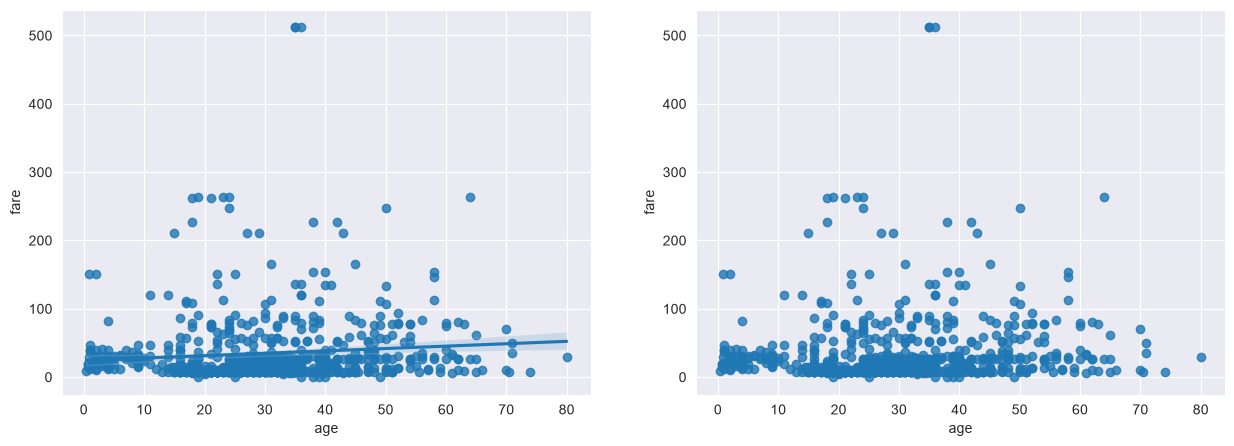

In [4]:
# 회귀선이 있는 산점도

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    x="age",
    y="fare",
    data=titanic,
    ax=axes[0]
)

sns.regplot(
    x="age",
    y="fare",
    data=titanic,
    ax=axes[1],
    fit_reg=False
)

plt.show()

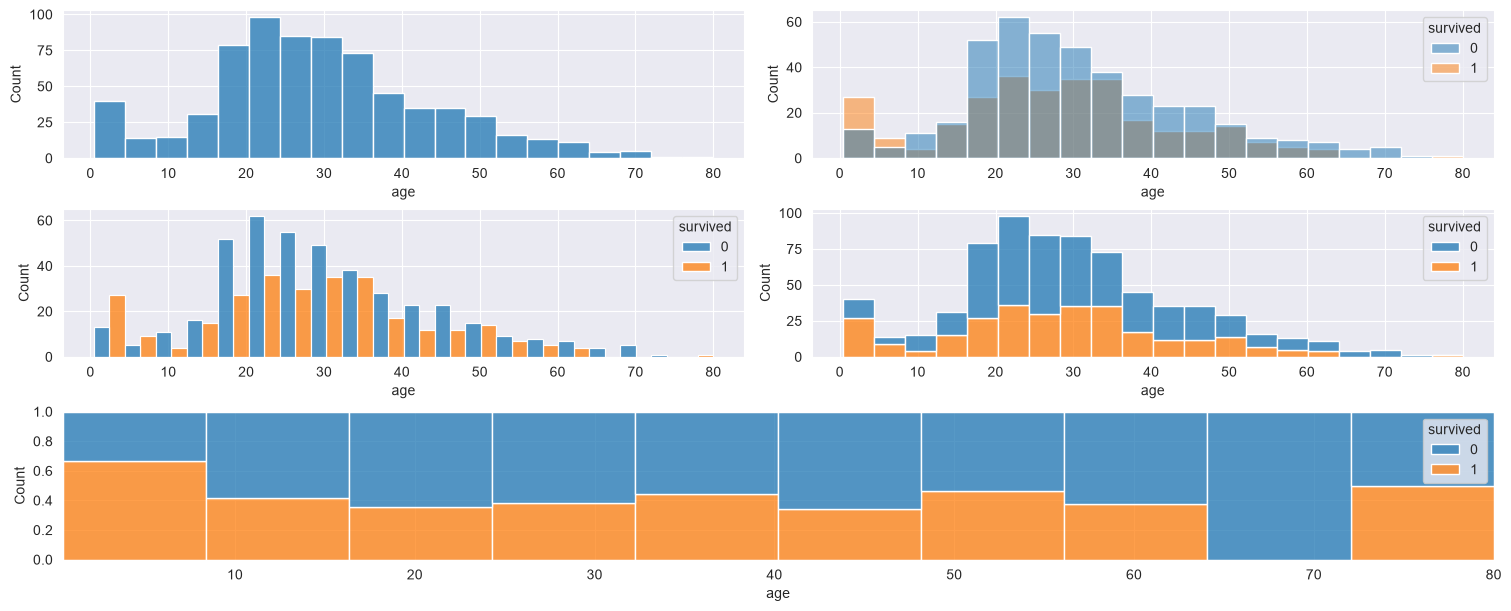

In [5]:
# 히스토그램/커널 밀도 함수

fig, axes = plt.subplot_mosaic(
    [["top_left", "top_right"],
     ["middle_left", "middle_right"],
    ["bottom", "bottom"]],
    figsize=(15, 6),
    constrained_layout=True)

sns.histplot(x="age", data=titanic, ax=axes["top_left"])

sns.histplot(x="age", hue="survived", data=titanic, ax=axes["top_right"])

sns.histplot(x="age", hue="survived", multiple="dodge", data=titanic, ax=axes["middle_left"])

sns.histplot(x="age", hue="survived", multiple="stack", data=titanic, ax=axes["middle_right"])

sns.histplot(x="age", hue="survived", multiple="fill", bins=10, data=titanic, ax=axes["bottom"])

plt.show()

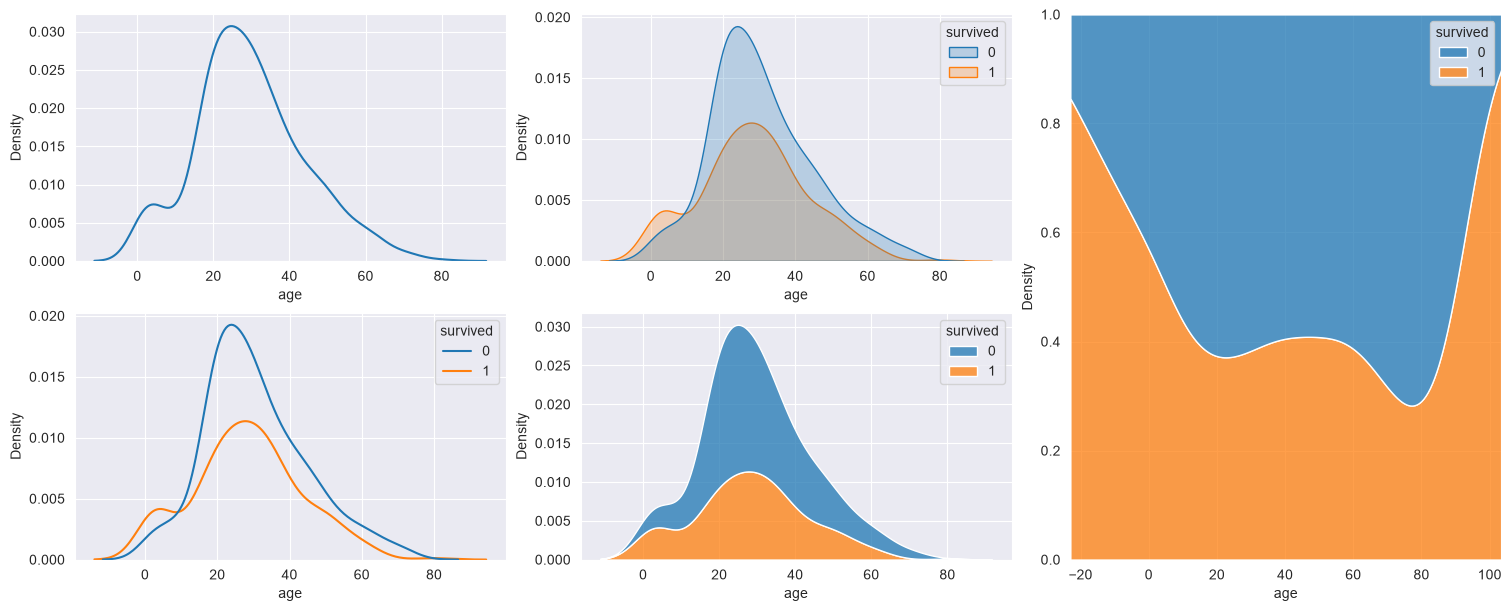

In [6]:
fig, axes = plt.subplot_mosaic([["top_left", "top_center", "right"],
                    ["bottom_left", "bottom_center", "right"]],
                    figsize=(15, 6),
                    constrained_layout=True)

sns.kdeplot(x="age", data=titanic, ax=axes["top_left"])

sns.kdeplot(x="age", hue="survived", data=titanic, ax=axes["bottom_left"])

sns.kdeplot(x="age", hue="survived", fill=True, data=titanic, ax=axes["top_center"])

sns.kdeplot(x="age", hue="survived", multiple="stack", data=titanic, ax=axes["bottom_center"])

sns.kdeplot(x="age", hue="survived", multiple="fill", bw_adjust=2.0, data=titanic, ax=axes["right"])

plt.show()

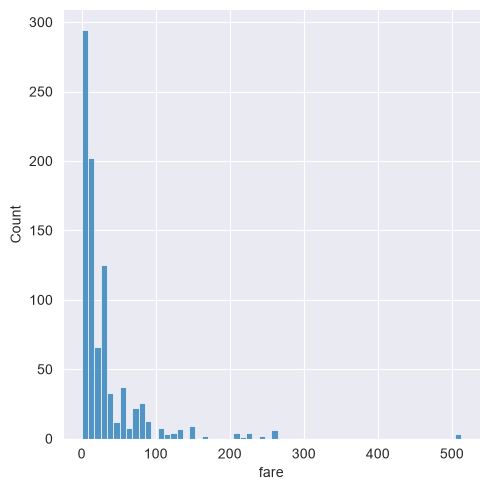

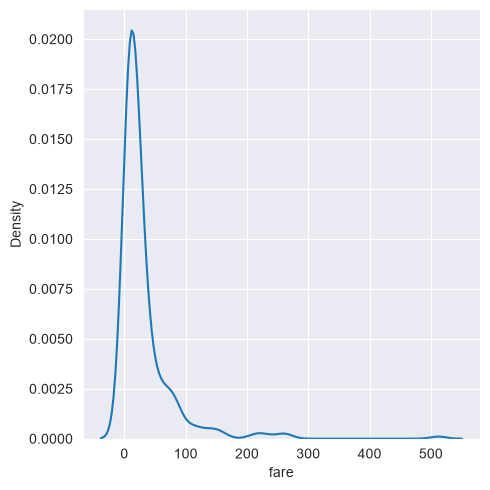

In [7]:
sns.displot(
    titanic["fare"],
    kind="hist"
)

plt.show()

sns.displot(titanic["fare"], kind="kde")
plt.show()

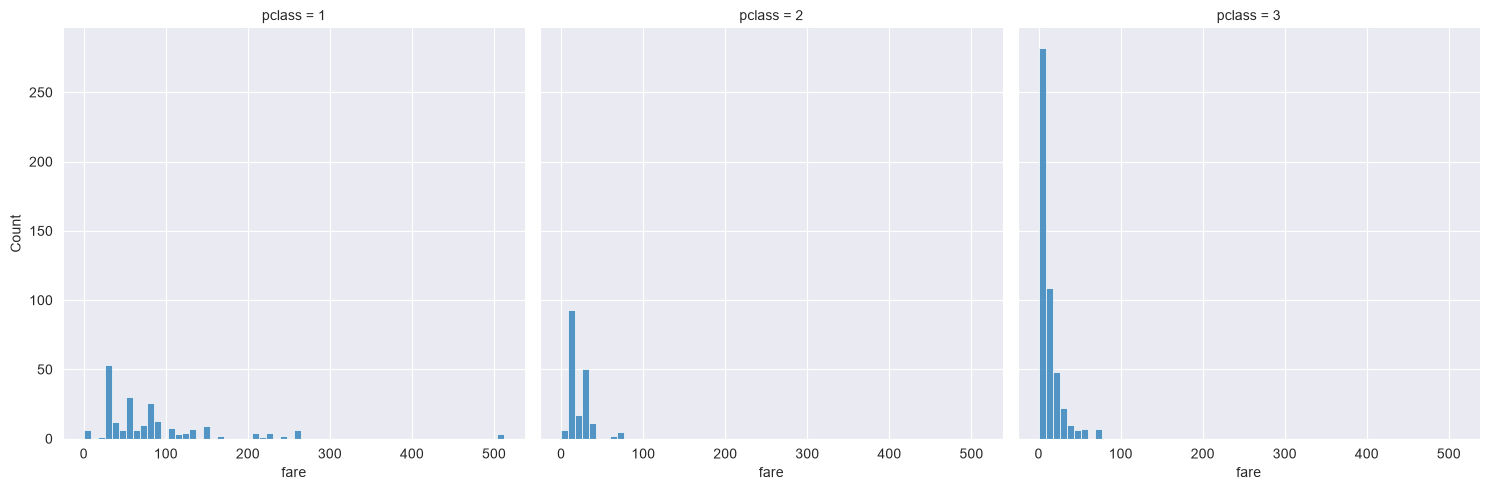

In [8]:
sns.displot(
    data=titanic,
    x="fare",
    col="pclass",
    kind="hist"
)

plt.show()

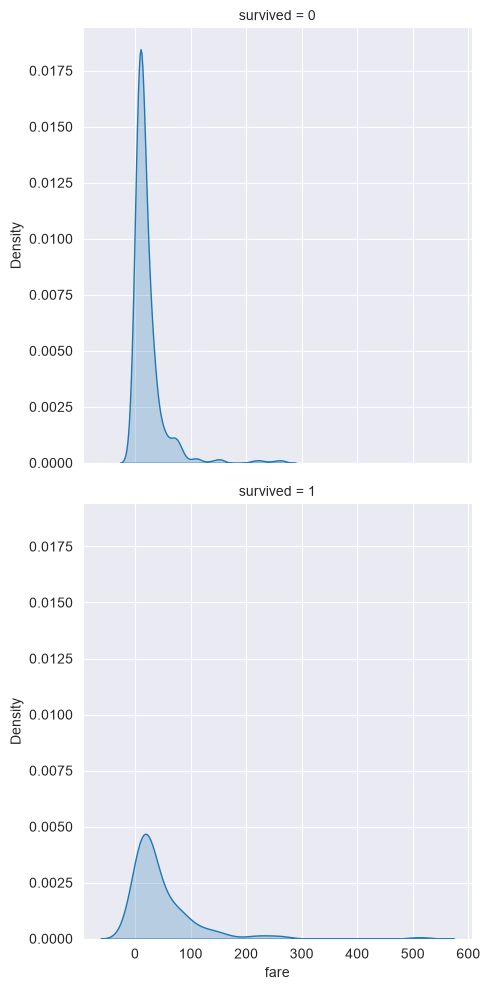

In [9]:
sns.displot(
    data=titanic,
    x="fare",
    row="survived",
    kind="kde",
    fill=True
)

plt.show()

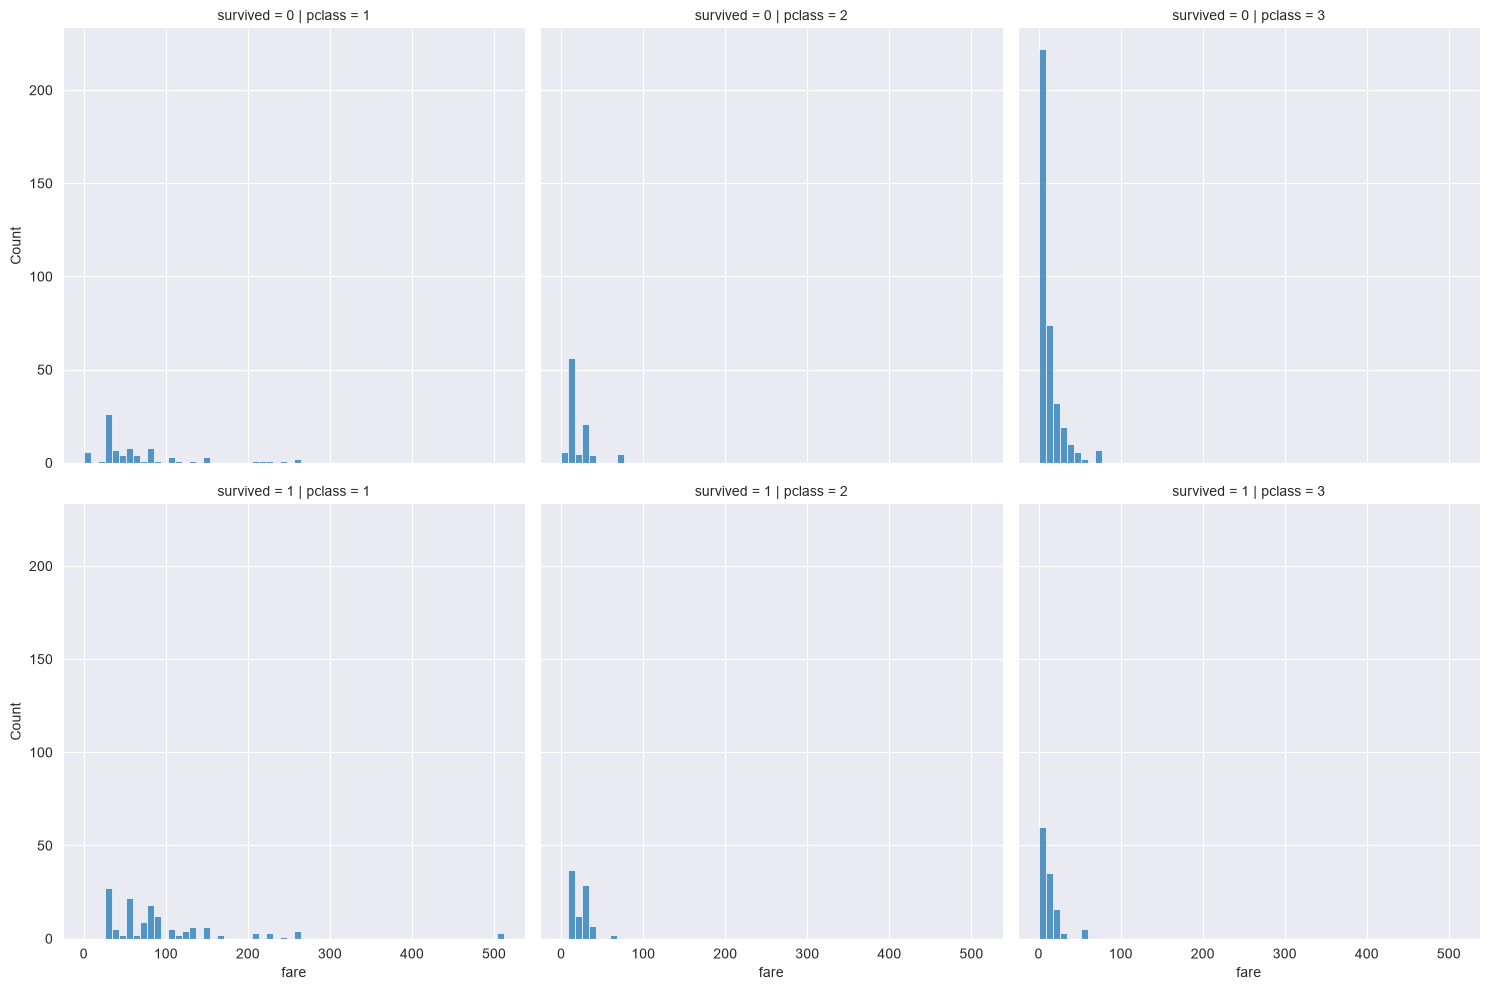

In [10]:
sns.displot(
    data=titanic,
    x="fare",
    col="pclass",
    row="survived"
)

plt.show()

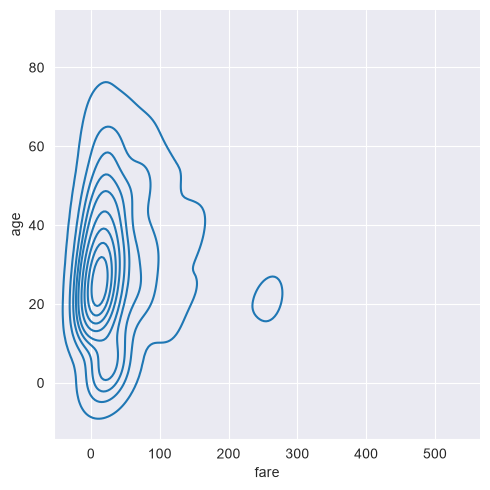

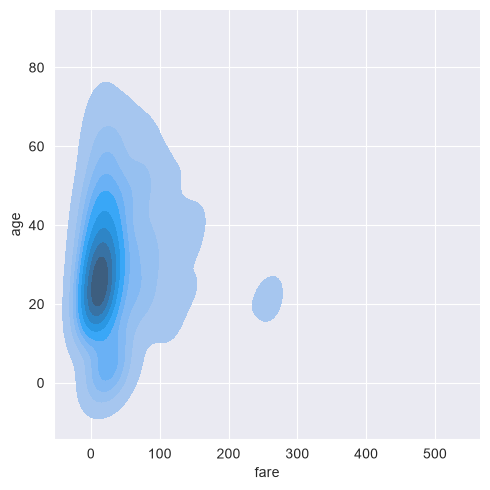

In [14]:
sns.displot(
    x="fare",
    y="age",
    data=titanic,
    kind="kde",
)

plt.show()

sns.displot(
    x="fare",
    y="age",
    data=titanic,
    kind="kde",
    fill="True"
)

plt.show()

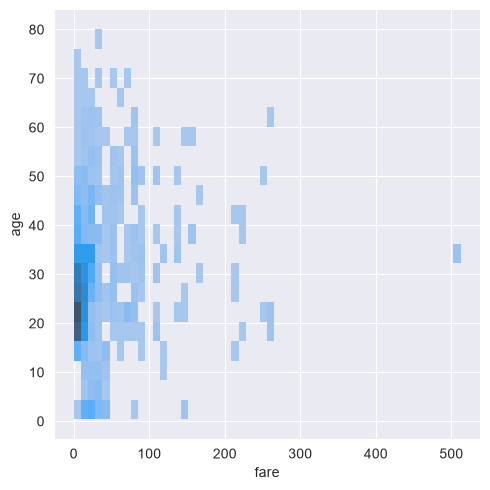

In [15]:
sns.displot(
    x="fare",
    y="age",
    data=titanic,
    kind="hist",
)

plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset("titanic")
sns.set_style("darkgrid")

table = titanic.pivot_table(
    index=["sex"],
    columns=["class"],
    aggfunc="size",
    observed=False
)
table

class,First,Second,Third
sex,,,
female,94,76,144
male,122,108,347


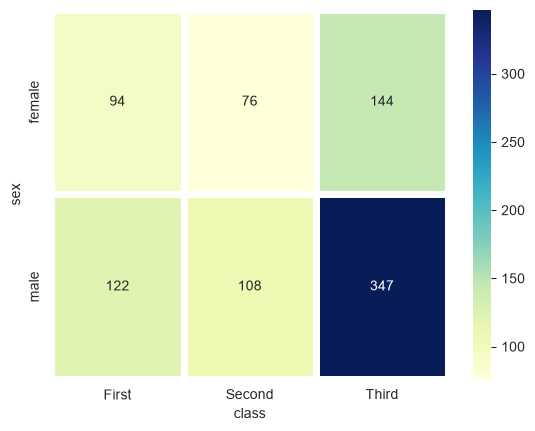

In [24]:
sns.heatmap(
    table,
    annot=True, fmt="d",
    cmap="YlGnBu",
    linewidth=5,
    cbar=True
)

plt.show()

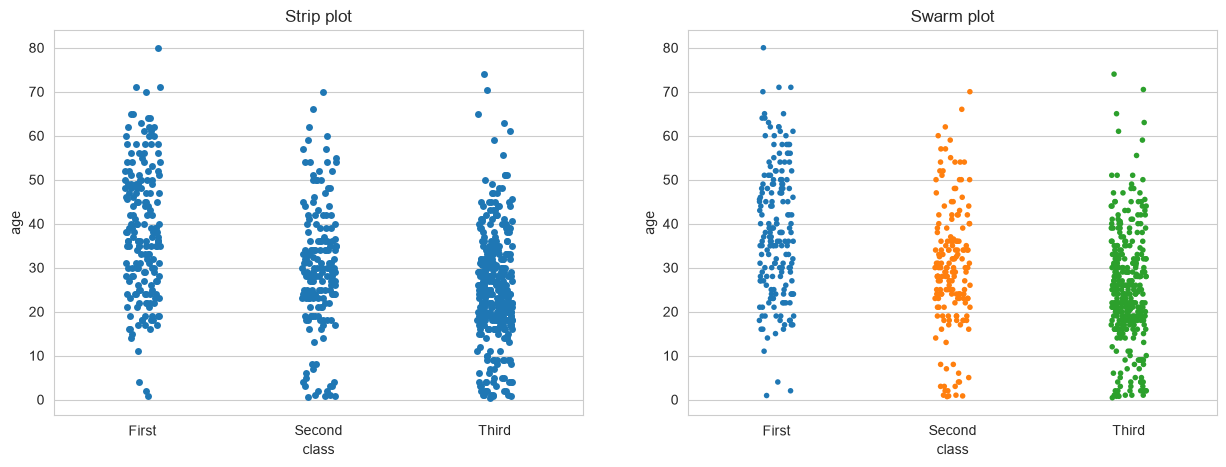

In [33]:
# 범주형 데이터의 산점도

sns.set_style("whitegrid")

fig, axes = plt.subplots(
        1, 2, figsize=(15, 5)
)

sns.stripplot(
    x="class",
    y="age",
    data=titanic,
    ax=axes[0]
)

sns.stripplot(
    x="class",
    y="age",
    data=titanic,
    ax=axes[1],
    hue="class",
    size=4
)

axes[0].set_title("Strip plot")
axes[1].set_title("Swarm plot")


plt.show()